In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE=42
TEST_SIZE=0.2

In [2]:
df = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df.head(3)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False


Посмотрим сначала на информацию про данные, чтобы понять, нужно ли заполнять пропуски(и чем лучше), удалять дубликаты и тд

In [3]:
print("Общая инфа")
print("=" * 50)
print('Размер: ', df.shape)
print("=" * 50)
print('Общая информация про каждый признак:')
print(df.info())
print("=" * 50)
print('Число пропусков у переменных у каждого признака:', df.isna().sum(), sep='\n')
print("=" * 50)
print('Число уникальных переменных у каждого признака:', df.nunique(), sep='\n')
print("=" * 50)
print('Число дупликатов:', df.duplicated().sum())
print("=" * 50)
print('Как распределен таргет: ', df['Transported'].value_counts().to_dict())
print("=" * 50)

Общая инфа
Размер:  (8693, 14)
Общая информация про каждый признак:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None
Число пропусков у переменных у каждого признака:
PassengerId       0


Заполним числовые признаки медианой, в категориальных добавим статус 'Undefined', а в бинарных сделаем пропуски нулями, и добавим столбец где 1 - был пропуск, 0 - не было пропуска

In [4]:
cols = df.columns.tolist()

print("Заполнение NaN'ов:")
if df.isna().sum().sum() > 0:
    for col in cols:
        miss_cnt = df[col].isna().sum()

        if df[col].isna().sum() > 0:
            #Числовые признаки
            if df[col].dtype in [np.float64, np.int64]:
                col_med = df[col].median()
                df[col] = df[col].fillna(col_med)
                df_test[col] = df_test[col].fillna(col_med)
                print(f'Столбец {col}: {miss_cnt} обьектов заполнены {col_med} медианой')
            else:
                #Категориальные
                if df[col].nunique() > 2:
                    df[col] = df[col].fillna('Undefined')
                    df_test[col] = df_test[col].fillna('Undefined')
                    print(f'Столбец {col}: {miss_cnt} обьектов заполнены "Undefined"')
                else:
                    #Бинарные
                    df.insert(cols.index(col) + 1,
                              f'{col}_is missed', 
                              np.where(df[col].isna() == True, 1, 0))
                    df[col] = df[col].fillna(0).astype(int)
                    
                    df_test.insert(cols.index(col) + 1,
                              f'{col}_is missed', 
                              np.where(df_test[col].isna() == True, 1, 0))
                    df_test[col] = df_test[col].fillna(0).astype(int)
                    print(f'Столбец {col}: {miss_cnt} обьектов заполнены 0, добавлен столбец со статусом пропущенных значений')
print("=" * 50)
print("Пропуски теперь в train:", df.isna().sum(), sep='\n')
print("=" * 50)
print("Пропуски теперь в test:", df_test.isna().sum(), sep='\n')
print("=" * 50)

Заполнение NaN'ов:
Столбец HomePlanet: 201 обьектов заполнены "Undefined"
Столбец CryoSleep: 217 обьектов заполнены 0, добавлен столбец со статусом пропущенных значений
Столбец Cabin: 199 обьектов заполнены "Undefined"
Столбец Destination: 182 обьектов заполнены "Undefined"
Столбец Age: 179 обьектов заполнены 27.0 медианой
Столбец VIP: 203 обьектов заполнены 0, добавлен столбец со статусом пропущенных значений
Столбец RoomService: 181 обьектов заполнены 0.0 медианой
Столбец FoodCourt: 183 обьектов заполнены 0.0 медианой
Столбец ShoppingMall: 208 обьектов заполнены 0.0 медианой
Столбец Spa: 183 обьектов заполнены 0.0 медианой
Столбец VRDeck: 188 обьектов заполнены 0.0 медианой
Столбец Name: 200 обьектов заполнены "Undefined"
Пропуски теперь в train:
PassengerId            0
HomePlanet             0
CryoSleep              0
CryoSleep_is missed    0
Cabin                  0
Destination            0
Age                    0
VIP_is missed          0
VIP                    0
RoomService     

In [5]:
target = df['Transported'].copy()
df = df.drop('Transported', axis=1)

def process_cabin(df):
    df = df.copy()
    df['Cabin_isMissed'] = df['Cabin'].isna().astype(int)
    
    # Извлекаем side: P → 1, S → 0
    df['Cabin_side'] = df['Cabin'].str.split('/').str[-1]  
    df['Cabin_side'] = df['Cabin_side'].map({'P': 1, 'S': 0})
    df['Cabin_side'] = df['Cabin_side'].fillna(0).astype(int)

    df = df.drop('Cabin', axis=1)
    return df

# Применяем к обоим
df = process_cabin(df)
df_test = process_cabin(df_test)

df['Group'] = df['PassengerId'].str[:4]
df_test['Group'] = df_test['PassengerId'].str[:4]

group_size = pd.concat([df['Group'], df_test['Group']]).value_counts()
df['GroupSize'] = df['Group'].map(group_size)
df_test['GroupSize'] = df_test['Group'].map(group_size)

df['IsAlone'] = (df['GroupSize'] == 1).astype(int)
df_test['IsAlone'] = (df_test['GroupSize'] == 1).astype(int)

df = df.drop('Group', axis=1)
df_test = df_test.drop('Group', axis=1)

df['Transported'] = target

print("Новые колонки:", [c for c in df.columns if 'Cabin' in c])

Новые колонки: ['Cabin_isMissed', 'Cabin_side']


In [6]:
df = df.drop(['Name', 'PassengerId'], axis=1)

passId = df_test['PassengerId']
df_test = df_test.drop(['Name', 'PassengerId'], axis=1)

df.head(3)

,HomePlanet,CryoSleep,CryoSleep_is missed,Destination,Age,VIP_is missed,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Cabin_isMissed,Cabin_side,GroupSize,IsAlone,Transported
0,Europa,0,0,TRAPPIST-1e,39.0,0,0,0.0,0.0,0.0,0.0,0.0,0,1,1,1,False
1,Earth,0,0,TRAPPIST-1e,24.0,0,0,109.0,9.0,25.0,549.0,44.0,0,0,1,1,True
2,Europa,0,0,TRAPPIST-1e,58.0,0,1,43.0,3576.0,0.0,6715.0,49.0,0,0,2,0,False


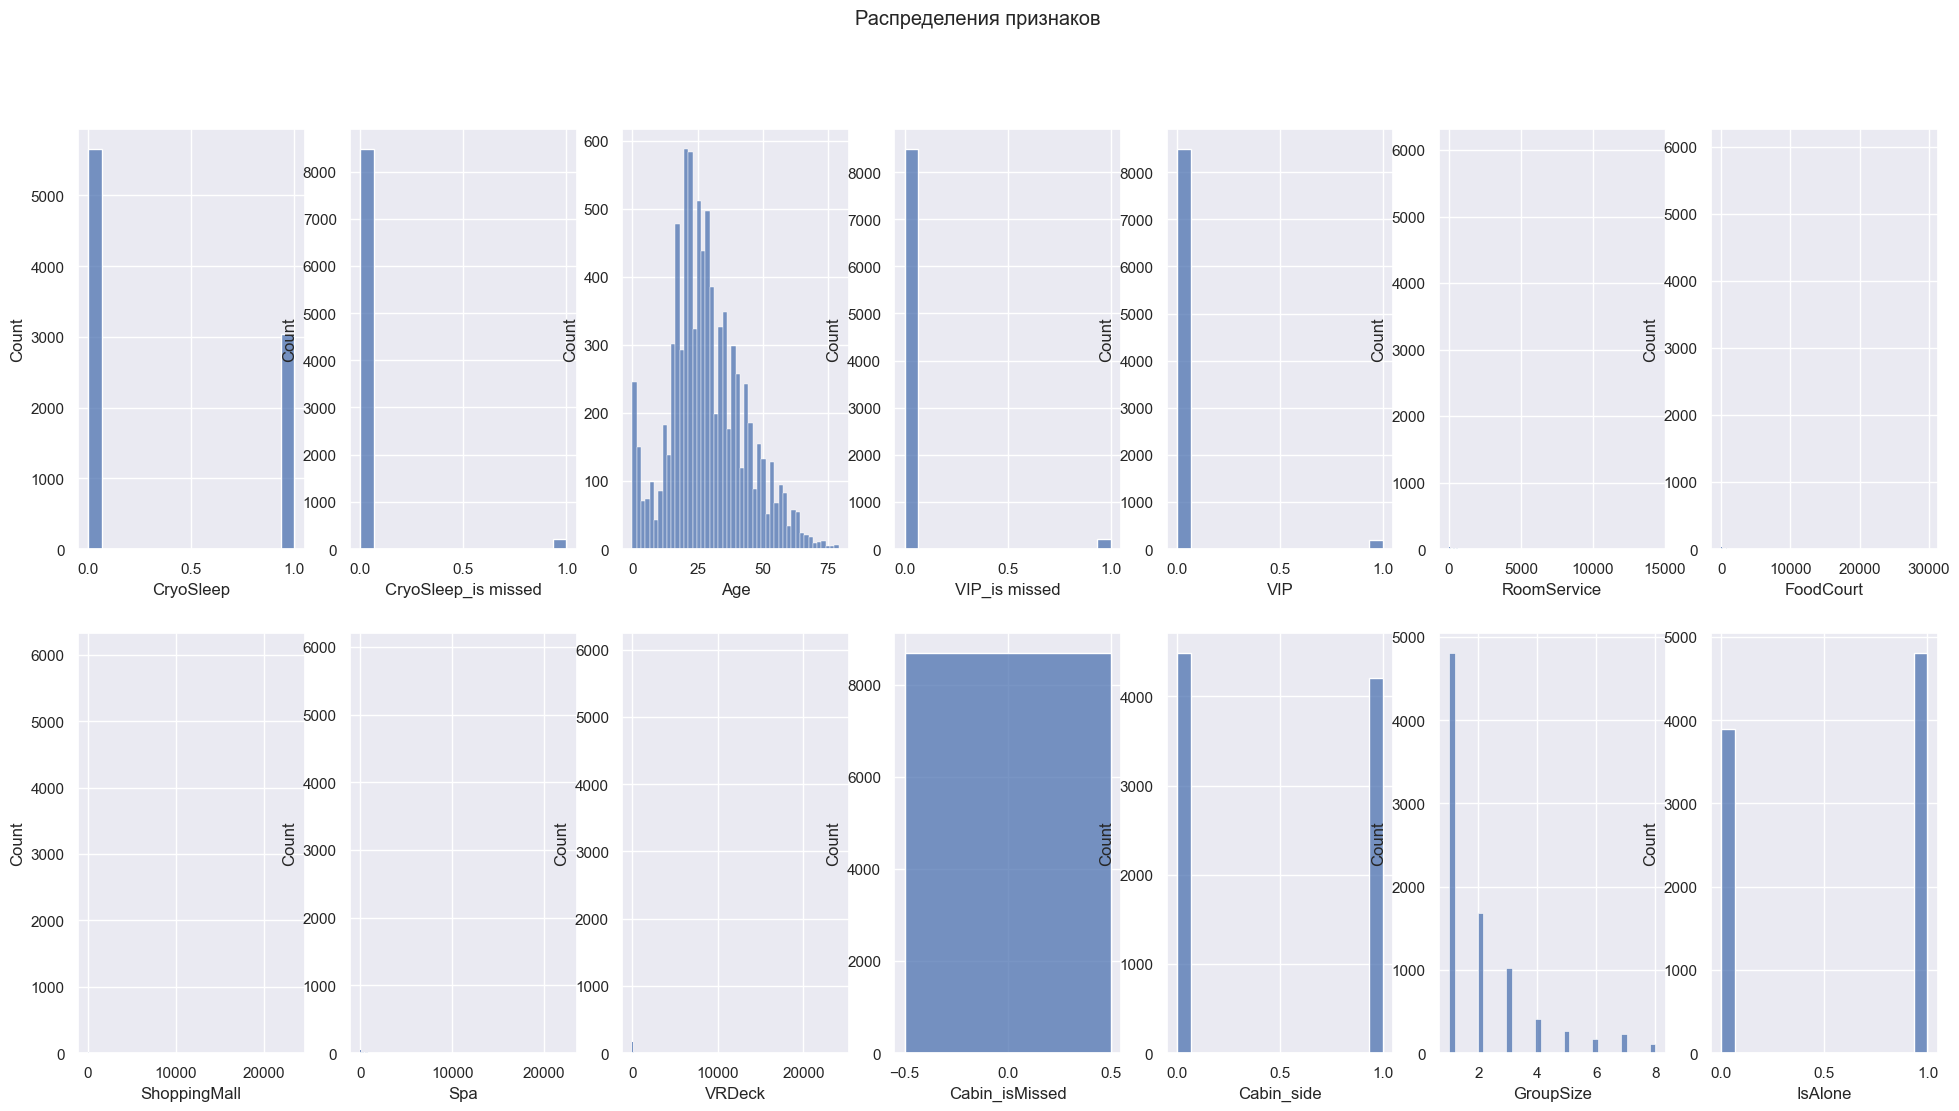

In [7]:
sns.set_theme(style='darkgrid', palette='deep')
fig, ax = plt.subplots(ncols=7, nrows=2, figsize=(24, 12))
cols = df.select_dtypes([float, int]).columns.to_numpy().reshape(2, 7)

for i in range(2):
    for j in range(7):
        sns.histplot(df[cols[i, j]], ax=ax[i, j])
fig.suptitle('Распределения признаков')
plt.show()

Видим, что распределения трат "странно" выглядят, стоит попробовать изменить их на другие признаки

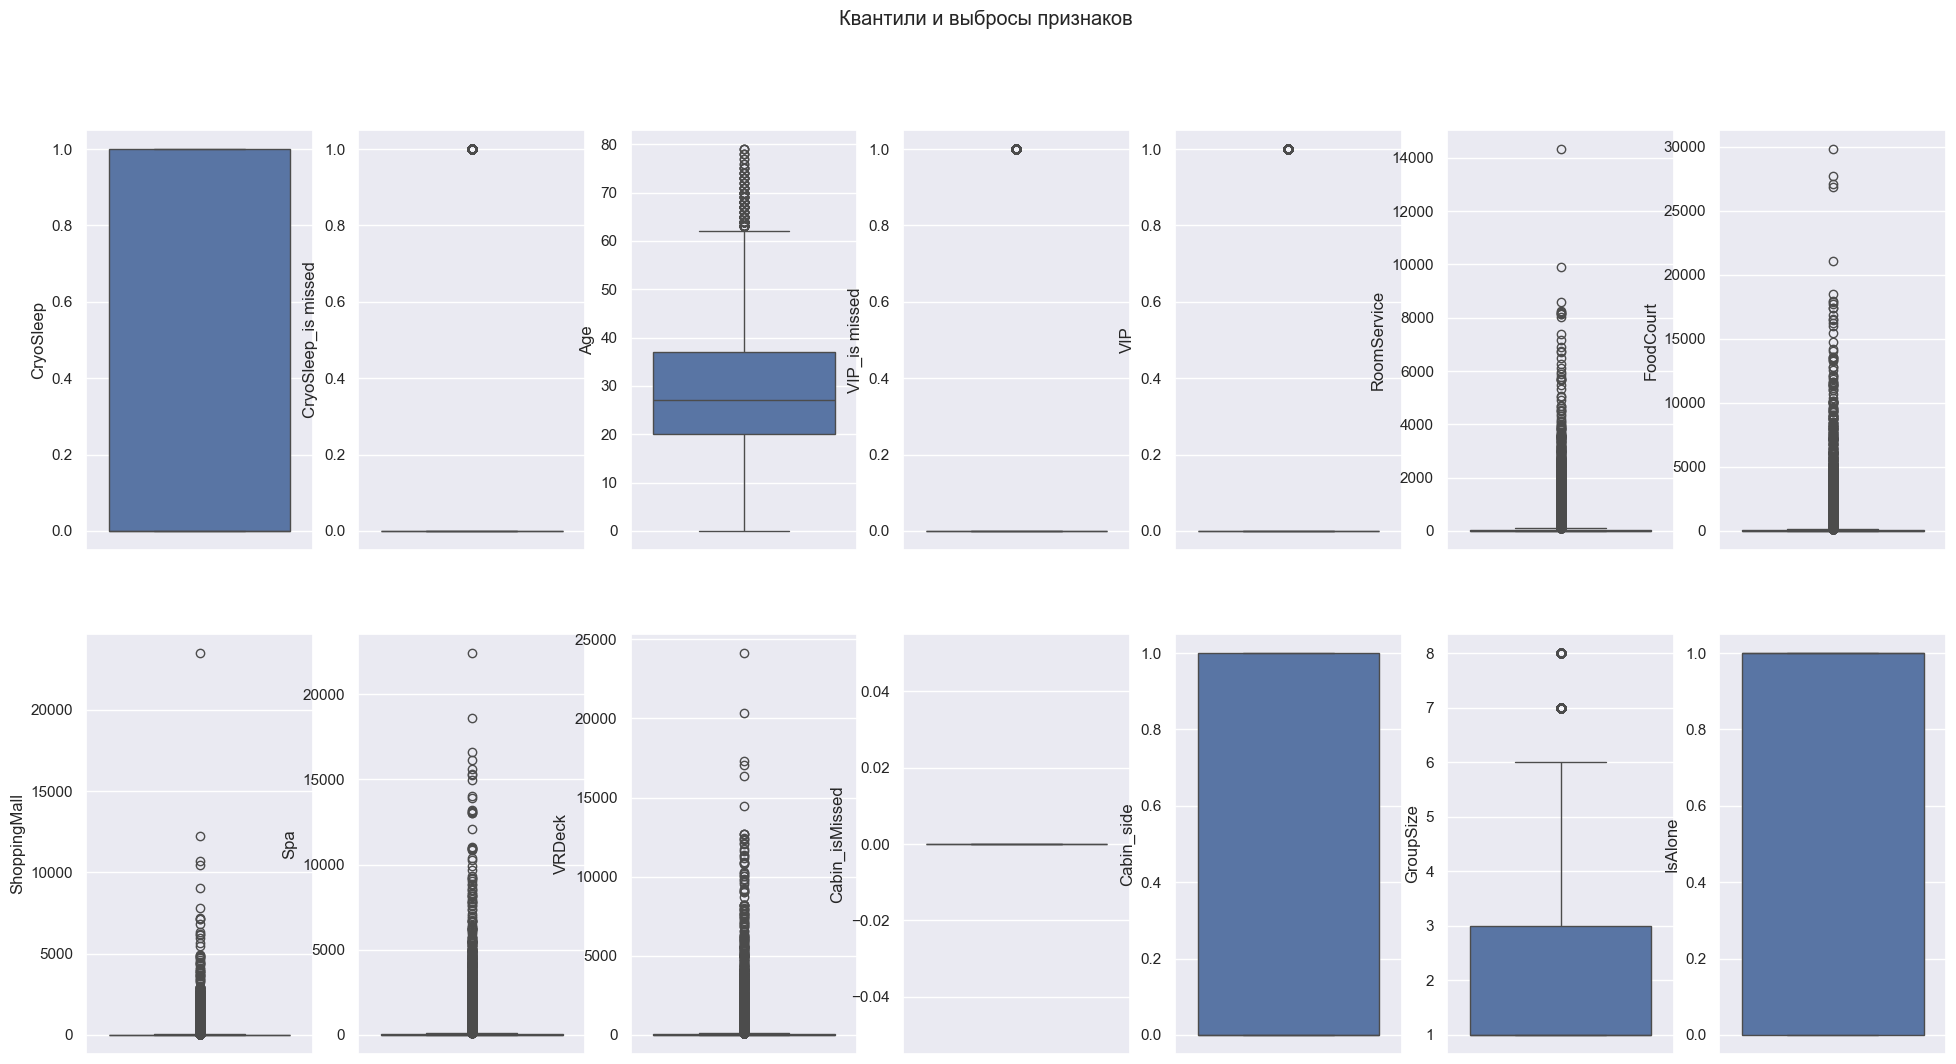

In [8]:
sns.set_theme(style='darkgrid', palette='deep')
fig, ax = plt.subplots(ncols=7, nrows=2, figsize=(24, 12))
cols = df.select_dtypes([float, int]).columns.to_numpy().reshape(2, 7)

for i in range(2):
    for j in range(7):
        sns.boxplot(df[cols[i, j]], ax=ax[i, j])
fig.suptitle('Квантили и выбросы признаков')
plt.show()

In [9]:
cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

df['Expenses'] = df[cols].sum(axis=1).astype(float)           
df['NoSpend'] = (df['Expenses'] == 0).astype(int)
df = df.drop(columns=cols)

df_test['Expenses'] = df_test[cols].sum(axis=1).astype(float)
df_test['NoSpend'] = (df_test['Expenses'] == 0).astype(int)
df_test = df_test.drop(columns=cols)

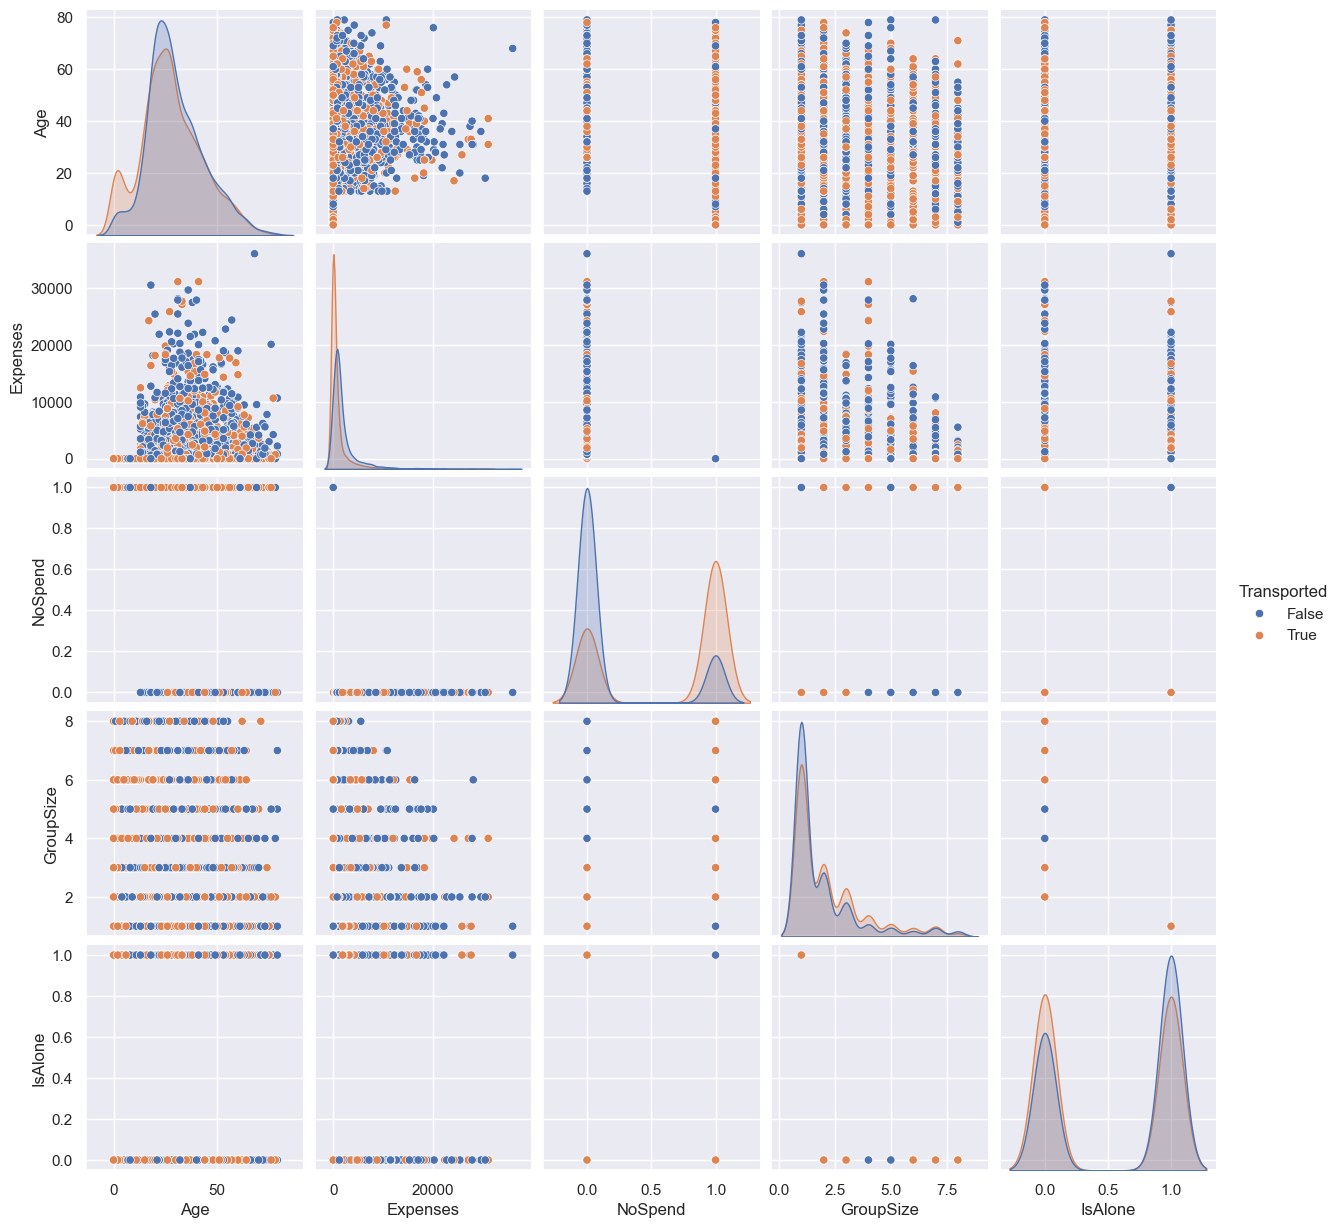

In [10]:
pairpl_cols = ['Age', 'Expenses', 'NoSpend', 'GroupSize', 'IsAlone', 'Transported']
sns.pairplot(df[pairpl_cols], hue='Transported')
plt.show()

Видим, что у нас попарные распределения плохо распределены на классы

In [11]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import randint, uniform

Нормируем возраст и доходы, и сделаем OneHotEncoding для категориальных признаков

In [12]:
scaler = StandardScaler()
num_cols = ['Age', 'Expenses']

scaler.fit(df[num_cols])                    
df[num_cols]     = scaler.transform(df[num_cols])
df_test[num_cols] = scaler.transform(df_test[num_cols])

cat_cols = ['HomePlanet', 'Destination']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe.fit(df[cat_cols])                        

codes_train = ohe.transform(df[cat_cols])
coded_train = pd.DataFrame(codes_train, 
                           columns=ohe.get_feature_names_out(),
                           index=df.index)

df_final = pd.concat([df.drop(columns=cat_cols), coded_train], axis=1)

codes_test = ohe.transform(df_test[cat_cols])
coded_test = pd.DataFrame(codes_test, 
                          columns=ohe.get_feature_names_out(),
                          index=df_test.index)

df_test_final = pd.concat([df_test.drop(columns=cat_cols), coded_test], axis=1)

Обучим модель(Пробовал сначала дерево, выдало плохой скор 0.4-0.5, потом попробовал random forest, стал скор 0.67, сделал CV и стал скор в районе 0.741, потом попробовал обучить градиентный бустинг на Random_search, вышел скор 0.739, в конце сделал blending и скор стал на тестовой 0.749

In [13]:
X, y = df_final.drop('Transported', axis=1), df_final['Transported'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE, shuffle=True, test_size=TEST_SIZE)

# GridSearch для RandomForest
param_grid = {
    'n_estimators': np.arange(50, 500, 50),
    'min_samples_leaf': np.arange(1, 10, 1)
}

rf = RandomForestClassifier(random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Лучшие параметры RF:", grid.best_params_)
print("Лучший score RF (CV):", grid.best_score_)

# RandomizedSearch для GradientBoosting
param_dist = {
    'n_estimators': randint(120, 400),
    'min_samples_leaf': randint(2, 7),
    'learning_rate': uniform(0.01, 2),
    'max_depth': randint(3, 8),
    'subsample': uniform(0.6, 0.4)
}

gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    random_state=RANDOM_STATE,
    scoring='accuracy',
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Лучшие параметры GB:", random_search.best_params_)
print("Лучший score GB (CV):", random_search.best_score_)

rf_best = grid.best_estimator_
gb_best = random_search.best_estimator_

Лучшие параметры RF: {'min_samples_leaf': np.int64(5), 'n_estimators': np.int64(350)}
Лучший score RF (CV): 0.7431718808993064
Лучшие параметры GB: {'learning_rate': np.float64(0.0210442342472048), 'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 200, 'subsample': np.float64(0.88453678109946)}
Лучший score GB (CV): 0.739432942502935


In [14]:
X_tr, X_ho, y_tr, y_ho = train_test_split(
    X_train, y_train,
    test_size=0.18,
    stratify=y_train,
    random_state=RANDOM_STATE
)

# Обучаем базовые модели на тренировочной части
rf_best.fit(X_tr, y_tr)
gb_best.fit(X_tr, y_tr)

ho_rf = rf_best.predict_proba(X_ho)[:, 1]
ho_gb = gb_best.predict_proba(X_ho)[:, 1]
ho_meta = np.column_stack([ho_rf, ho_gb])

#Теперь на тестовой смотрим и сохраняем в .csv
X_test = df_test_final

test_rf = rf_best.predict_proba(X_test)[:, 1]
test_gb = gb_best.predict_proba(X_test)[:, 1]
test_meta = np.column_stack([test_rf, test_gb])

meta = LogisticRegression(
    C=0.6,
    solver='liblinear',
    random_state=RANDOM_STATE,
    max_iter=1000
)

meta.fit(ho_meta, y_ho)

# Финальные предсказания
final_proba = meta.predict_proba(test_meta)[:, 1]
final_pred = final_proba > 0.5

submission = pd.DataFrame({
    'PassengerId': passId,
    'Transported': final_pred
})

submission.to_csv('submission_blend_rf_gb_logreg.csv', index=False)

print("Сохранён файл: submission_blend_rf_gb_logreg.csv")
print(submission.head(8))

Сохранён файл: submission_blend_rf_gb_logreg.csv
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01        False
4     0023_01        False
5     0027_01        False
6     0029_01         True
7     0032_01         True
